# Hierarchical analysis

In [34]:
!!pip install squarify
!!pip install country-converter

['Requirement already satisfied: country-converter in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.3.1)',
 'Requirement already satisfied: pandas>=1.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from country-converter) (2.3.2)',
 'Requirement already satisfied: numpy>=1.26.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas>=1.0->country-converter) (2.3.3)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas>=1.0->country-converter) (2.9.0.post0)',
 'Requirement already satisfied: pytz>=2020.1 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas>=1.0->country-converter) (2025.2)',
 'Requirement already satisfied: tzdata>=2022.7 in c:\\users\\yusel\\documents\\github\\visualization-tools-i

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import squarify
import country_converter as coco
import warnings

In [ ]:
df = pd.read_csv('data/01_gdp_population.csv')

In [40]:
print(f"Dimensiones: {df.shape[0]} países × {df.shape[1]} variables")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeros registros:")
display(df.head())

Dimensiones: 193 países × 4 variables

Columnas: ['Country Name', 'Country Code', 'Population', 'GDP']

Primeros registros:


,Country Name,Country Code,Population,GDP
0,Afghanistan,AFG,42647492,0.000000
1,Angola,AGO,37885849,2122.083690
2,Albania,ALB,2714617,10011.627986
3,Andorra,AND,81938,49303.673390
4,United Arab Emirates,ARE,10876981,49377.564338


In [39]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  193 non-null    object 
 1   Country Code  193 non-null    object 
 2   Population    193 non-null    int64  
 3   GDP           193 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ KB
None
         Population            GDP
count  1.930000e+02     193.000000
mean   4.196121e+07   16364.426623
std    1.508721e+08   23447.224829
min    9.646000e+03       0.000000
25%    2.126324e+06    1743.988884
50%    9.515236e+06    6416.097090
75%    3.196496e+07   22771.416892
max    1.450936e+09  137516.587324


In [42]:
df_clean = df.copy()
df_clean = df_clean[df_clean['GDP'] > 0].copy()

print(f"\n Después de limpieza: {df_clean.shape[0]} países con datos completos")


 Después de limpieza: 175 países con datos completos


In [45]:
cc = coco.CountryConverter()

# Convertir códigos a continentes
df_clean['Continent'] = cc.pandas_convert(
    series=df_clean['Country Code'], 
    to='continent'
)

def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'Americas' and row['Country Code'] not in ['USA', 'CAN']:
        return 'América Latina'
    elif row['Continent'] == 'Americas':
        return 'Norteamérica'
    elif row['Continent'] == 'Africa':
        return 'África'
    elif row['Continent'] == 'Oceania':
        return 'Oceanía'
    elif row['Continent'] == 'Europe':
        return 'Europa'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

df_clean['Region'] = df_clean.apply(ajustar_region, axis=1)
df_clean['Region'].fillna('Otros', inplace=True)

# Crear variables adicionales para análisis
df_clean['GDP_billions'] = df_clean['GDP'] * df_clean['Population'] / 1e9
df_clean['Population_millions'] = df_clean['Population'] / 1e6

print("\n Distribución de países por región:")
region_counts = df_clean['Region'].value_counts()
display(region_counts)

print("\n PIB Total por Región (miles de millones USD):")
regional_gdp = df_clean.groupby('Region')['GDP_billions'].sum().sort_values(ascending=False)
display(regional_gdp.round(2))


 Distribución de países por región:


C:\Users\yusel\AppData\Local\Temp\ipykernel_8208\3426427732.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Region'].fillna('Otros', inplace=True)


Region
África     51
Europa     40
Asia       40
America    33
Oceanía    11
Name: count, dtype: int64


 PIB Total por Región (miles de millones USD):


Region
America    38077.31
Asia       37289.39
Europa     27093.26
África      2648.92
Oceanía     2056.02
Name: GDP_billions, dtype: float64

In [48]:
import country_converter as coco

cc = coco.CountryConverter()

print(" Clasificando países por continente/región...")

# Convertir códigos a continentes automáticamente
df_clean['Continent'] = cc.pandas_convert(
    series=df_clean['Country Code'], 
    to='continent'
)

# Función para ajustar clasificación según necesidades de TCF
def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'Americas' and row['Country Code'] not in ['USA', 'CAN']:
        return 'América Latina'
    elif row['Continent'] == 'Americas':
        return 'Norteamérica'
    elif row['Continent'] == 'Africa':
        return 'África'
    elif row['Continent'] == 'Oceania':
        return 'Oceanía'
    elif row['Continent'] == 'Europe':
        return 'Europa'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

# Aplicar clasificación personalizada
df_clean['Region'] = df_clean.apply(ajustar_region, axis=1)

# Manejar posibles valores no reconocidos
df_clean['Region'] = df_clean['Region'].fillna('Otros')
print(" Distribución de países por región:")
region_counts = df_clean['Region'].value_counts()
display(region_counts)

# Análisis agregado por región
print("\n PIB Total por Región (en miles de millones USD):")
regional_gdp = df_clean.groupby('Region')['GDP_billions'].sum().sort_values(ascending=False)
display(regional_gdp)


 Clasificando países por continente/región...
 Distribución de países por región:


Region
África     51
Europa     40
Asia       40
America    33
Oceanía    11
Name: count, dtype: int64


 PIB Total por Región (en miles de millones USD):


Region
America    38077.310446
Asia       37289.394759
Europa     27093.261296
África      2648.922397
Oceanía     2056.018325
Name: GDP_billions, dtype: float64

## MÉTRICAS CLAVE PARA DECISIÓN DE INVERSIÓN

In [50]:
# Análisis agregado por región
regional_analysis = df_clean.groupby('Region').agg({
    'GDP_billions': 'sum',
    'GDP': 'mean',
    'Population': 'sum',
    'Country Name': 'count'
}).round(2)

regional_analysis.columns = ['PIB Total (B USD)', 'PIB per cápita Promedio', 
                              'Población Total', 'Número de Países']
regional_analysis = regional_analysis.sort_values('PIB Total (B USD)', ascending=False)

print("\n RESUMEN EJECUTIVO POR REGIÓN:")
display(regional_analysis)

# Top países por PIB Total
print("\n TOP 15 PAÍSES POR PIB TOTAL (Mayor Capacidad de Compra):")
top_countries = df_clean.nlargest(15, 'GDP_billions')[
    ['Country Name', 'Region', 'GDP_billions', 'GDP', 'Population_millions']
].copy()
top_countries.columns = ['País', 'Región', 'PIB Total (B USD)', 
                         'PIB per cápita', 'Población (M)']
display(top_countries.round(2))


 RESUMEN EJECUTIVO POR REGIÓN:


,PIB Total (B USD),PIB per cápita Promedio,Población Total,Número de Países
Region,,,,
America,38077.31,16749.47,1000399073,33
Asia,37289.39,16606.89,4565759025,40
Europa,27093.26,40842.83,740945177,40
África,2648.92,2885.49,1365780509,51
Oceanía,2056.02,14586.68,45710762,11



 TOP 15 PAÍSES POR PIB TOTAL (Mayor Capacidad de Compra):


,País,Región,PIB Total (B USD),PIB per cápita,Población (M)
182,United States,America,29184.89,85809.90,340.11
32,China,Asia,18743.80,13303.15,1408.98
44,Germany,Europa,4659.93,55800.22,83.51
86,Japan,Asia,4026.21,32475.89,123.98
77,India,Asia,3912.69,2696.66,1450.94
61,United Kingdom,Europa,3643.83,52636.79,69.23
58,France,Europa,3162.08,46150.49,68.52
83,Italy,Europa,2372.77,40226.05,58.99
29,Canada,America,2241.25,54282.62,41.29
23,Brazil,America,2179.41,10280.31,212.00


 VISUALIZACIÓN 1: TREEMAP ESTÁTICO
Propósito: Vista general de capacidad de compra por región y país


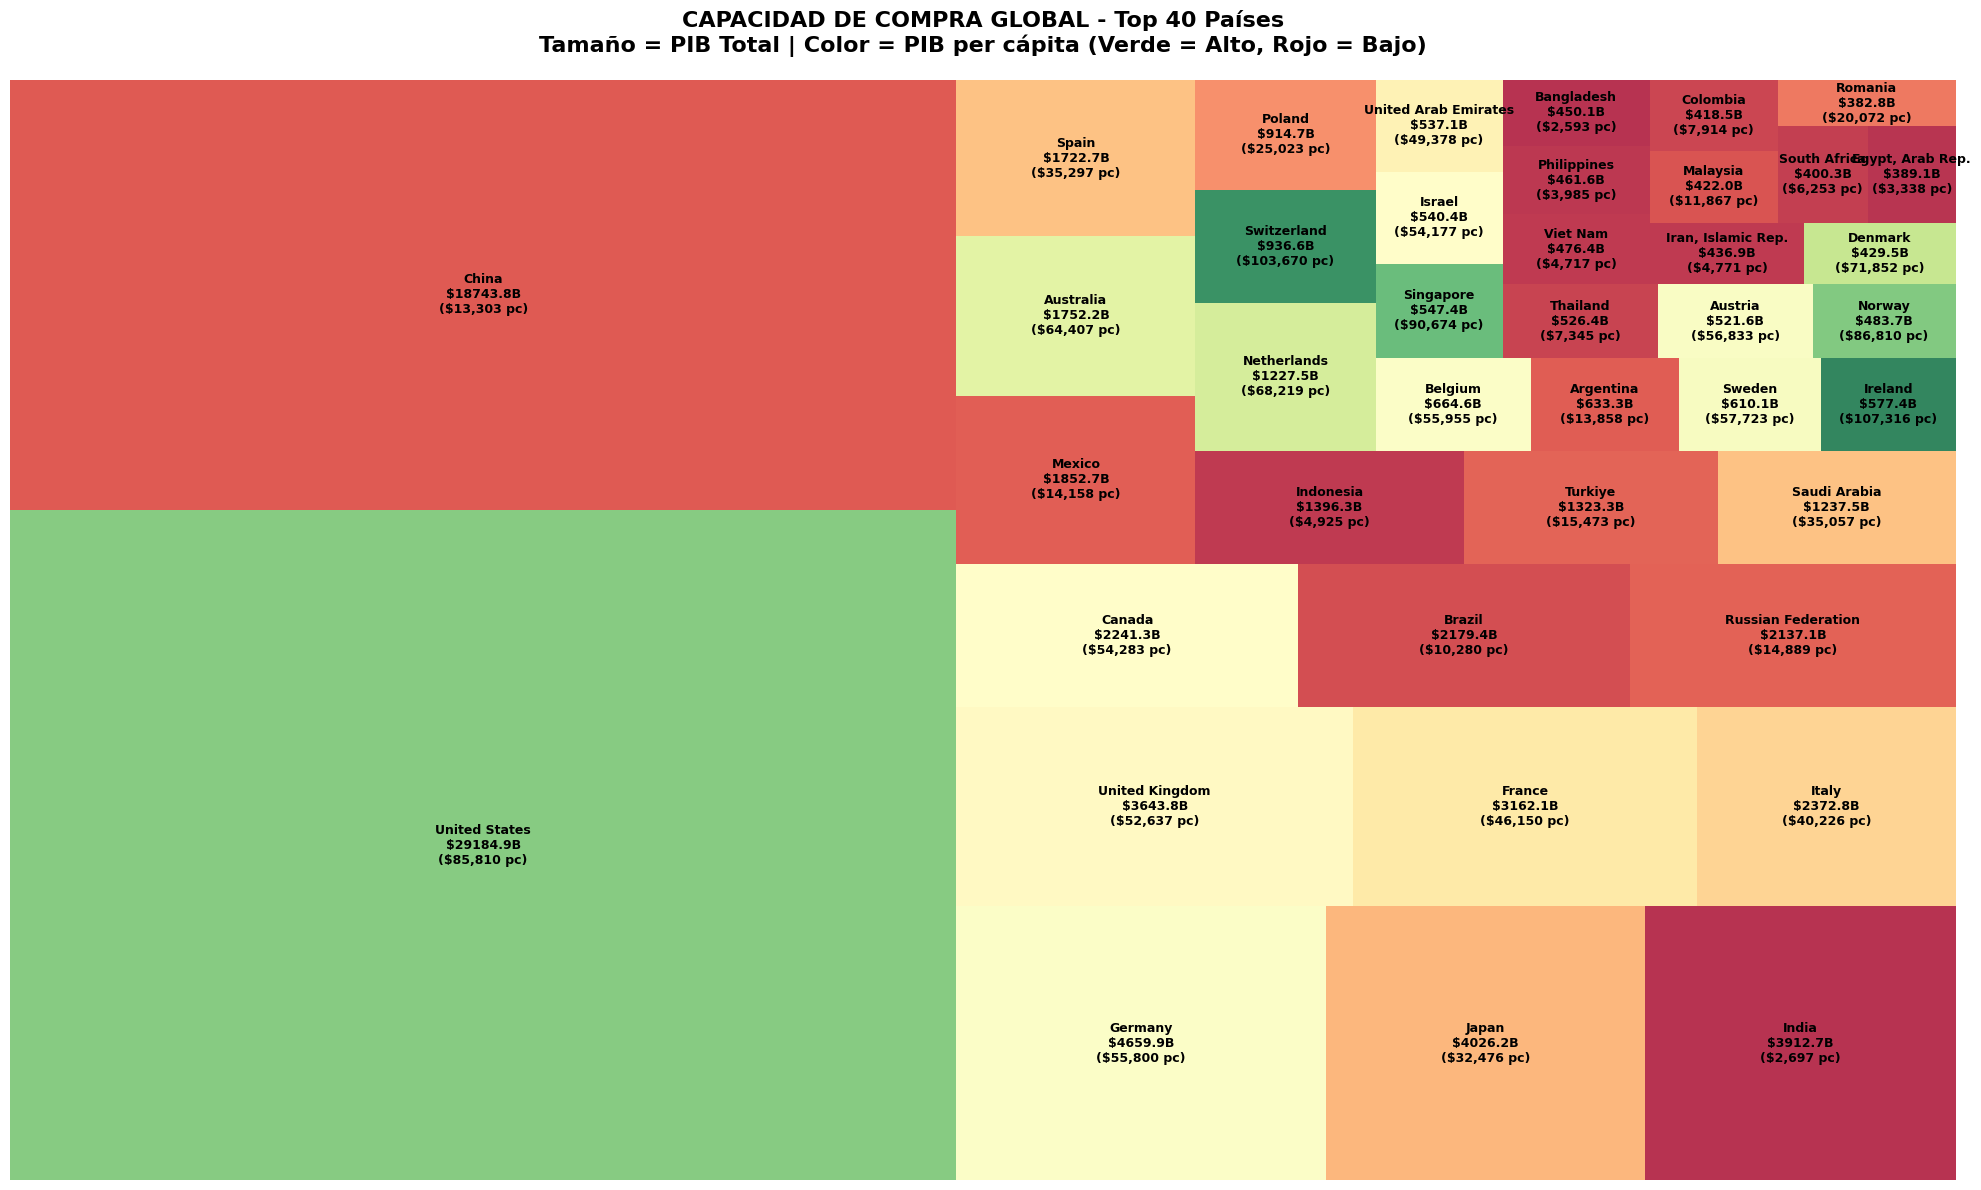


 INSIGHT CLAVE:
   Los países más grandes representan los mercados con mayor capacidad
   de compra total. El color indica el poder adquisitivo individual.


In [53]:
print(" VISUALIZACIÓN 1: TREEMAP ESTÁTICO")
print("Propósito: Vista general de capacidad de compra por región y país")


# Preparar datos para treemap - Top 40 países
df_treemap = df_clean.nlargest(40, 'GDP_billions').copy()

fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Calcular color basado en PIB per cápita
norm = plt.Normalize(vmin=df_treemap['GDP'].min(), vmax=df_treemap['GDP'].max())
colors = plt.cm.RdYlGn(norm(df_treemap['GDP']))

# Crear treemap
squarify.plot(
    sizes=df_treemap['GDP_billions'],
    label=[f"{row['Country Name']}\n${row['GDP_billions']:.1f}B\n(${row['GDP']:,.0f} pc)" 
           for _, row in df_treemap.iterrows()],
    color=colors,
    alpha=0.8,
    text_kwargs={'fontsize': 9, 'weight': 'bold'},
    ax=ax
)

ax.set_title('CAPACIDAD DE COMPRA GLOBAL - Top 40 Países\n' + 
             'Tamaño = PIB Total | Color = PIB per cápita (Verde = Alto, Rojo = Bajo)',
             fontsize=16, weight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n INSIGHT CLAVE:")
print("   Los países más grandes representan los mercados con mayor capacidad")
print("   de compra total. El color indica el poder adquisitivo individual.")


In [69]:
print("\n" + "=" * 80)
print(" VISUALIZACIÓN 2: TREEMAP INTERACTIVO JERÁRQUICO")
print("Propósito: Exploración interactiva de Región → País")
print("=" * 80)

# Preparar datos para treemap interactivo
df_interactive = df_clean.copy()

df_interactive['PIB_label'] = df_interactive['GDP_billions'].apply(lambda x: f"${x:.1f}B")
df_interactive['GDP_pc_label'] = df_interactive['GDP'].apply(lambda x: f"${x:,.0f}")

fig = px.treemap(
    df_interactive,
    path=['Region', 'Country Name'],
    values='GDP_billions',
    color='GDP',
    color_continuous_scale='RdYlGn',
    hover_data={
        'GDP_billions': ':.2f',
        'GDP': ':.0f',
        'Population_millions': ':.2f'
    },
    labels={
        'GDP_billions': 'PIB Total (B USD)',
        'GDP': 'PIB per cápita (USD)',
        'Population_millions': 'Población (M)',
        'Region': 'Región',
        'Country Name': 'País'
    },
    title='<b>JERARQUÍA DE CAPACIDAD DE COMPRA: Región → País</b><br>' +
          '<sub>Haz click en las regiones para explorar países | Tamaño = PIB Total | Color = PIB per cápita</sub>'
)

fig.update_layout(
    height=700,
    font=dict(size=12),
    margin=dict(t=100, l=10, r=10, b=10)
)

fig.update_traces(
    textposition="middle center",
    textfont_size=11,
    marker=dict(line=dict(width=2, color='white'))
)

fig.show()

print("\n INSIGHT CLAVE:")
print("   Haz click en cada región para ver la distribución detallada de países.")
print("   Identifica mercados grandes (tamaño) con alto poder adquisitivo (verde).")


 VISUALIZACIÓN 2: TREEMAP INTERACTIVO JERÁRQUICO
Propósito: Exploración interactiva de Región → País



 INSIGHT CLAVE:
   Haz click en cada región para ver la distribución detallada de países.
   Identifica mercados grandes (tamaño) con alto poder adquisitivo (verde).


In [70]:
print("\n" + "=" * 80)
print(" VISUALIZACIÓN 3: SUNBURST CHART")
print("Propósito: Visualizar proporción y jerarquía de mercados")
print("=" * 80)

# Top 50 países para mejor visualización
df_sunburst = df_clean.nlargest(50, 'GDP_billions').copy()

fig = px.sunburst(
    df_sunburst,
    path=['Region', 'Country Name'],
    values='GDP_billions',
    color='GDP',
    color_continuous_scale='Viridis',
    hover_data={
        'GDP_billions': ':.2f',
        'GDP': ':.0f'
    },
    labels={
        'GDP_billions': 'PIB Total (B USD)',
        'GDP': 'PIB per cápita (USD)',
        'Region': 'Región',
        'Country Name': 'País'
    },
    title='<b>ESTRUCTURA JERÁRQUICA DE MERCADOS - Top 50</b><br>' +
          '<sub>Centro = Regiones | Anillos exteriores = Países | Color = PIB per cápita</sub>'
)

fig.update_layout(
    height=700,
    font=dict(size=12),
    margin=dict(t=100, l=10, r=10, b=10)
)

fig.update_traces(
    textfont_size=10,
    marker=dict(line=dict(width=2, color='white'))
)

fig.show()

print("\n INSIGHT CLAVE:")
print("   Las secciones más grandes indican mayor participación en el mercado global.")
print("   Haz click para explorar la contribución de cada país dentro de su región.")


 VISUALIZACIÓN 3: SUNBURST CHART
Propósito: Visualizar proporción y jerarquía de mercados



 INSIGHT CLAVE:
   Las secciones más grandes indican mayor participación en el mercado global.
   Haz click para explorar la contribución de cada país dentro de su región.


In [71]:
print("\n" + "=" * 80)
print(" VISUALIZACIÓN 4: COMPARACIÓN REGIONAL DETALLADA")
print("Propósito: Comparar regiones según múltiples dimensiones")
print("=" * 80)

# Crear subplots para comparación multi-dimensional
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'PIB Total por Región (Capacidad de Compra)',
        'PIB per cápita Promedio (Poder Adquisitivo)',
        'Número de Países por Región',
        'Población Total por Región'
    ),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

regional_summary = df_clean.groupby('Region').agg({
    'GDP_billions': 'sum',
    'GDP': 'mean',
    'Country Name': 'count',
    'Population': 'sum'
}).round(2)

regional_summary = regional_summary.sort_values('GDP_billions', ascending=False)

colors_sequential = px.colors.sequential.Viridis

# Subplot 1: PIB Total
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['GDP_billions'],
        marker_color=colors_sequential[2],
        text=regional_summary['GDP_billions'].round(0),
        textposition='outside',
        name='PIB Total'
    ),
    row=1, col=1
)

# Subplot 2: PIB per cápita
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['GDP'],
        marker_color=colors_sequential[4],
        text=regional_summary['GDP'].round(0),
        textposition='outside',
        name='PIB per cápita'
    ),
    row=1, col=2
)

# Subplot 3: Número de países
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['Country Name'],
        marker_color=colors_sequential[6],
        text=regional_summary['Country Name'],
        textposition='outside',
        name='Países'
    ),
    row=2, col=1
)

# Subplot 4: Población
fig.add_trace(
    go.Bar(
        x=regional_summary.index,
        y=regional_summary['Population'] / 1e6,
        marker_color=colors_sequential[8],
        text=(regional_summary['Population'] / 1e6).round(0),
        textposition='outside',
        name='Población (M)'
    ),
    row=2, col=2
)

# Actualizar layout
fig.update_xaxes(tickangle=-45)
fig.update_yaxes(title_text="Miles de millones USD", row=1, col=1)
fig.update_yaxes(title_text="USD per cápita", row=1, col=2)
fig.update_yaxes(title_text="Cantidad", row=2, col=1)
fig.update_yaxes(title_text="Millones", row=2, col=2)

fig.update_layout(
    height=800,
    showlegend=False,
    title_text="<b>ANÁLISIS COMPARATIVO REGIONAL - TERRA COTTA FOODS</b>",
    title_font_size=16,
    font=dict(size=10)
)

fig.show()

print("\n INSIGHT CLAVE:")
print("   Vista completa de las dimensiones clave para evaluar regiones.")
print("   Combina capacidad de compra (PIB Total) con poder adquisitivo (PIB pc).")


 VISUALIZACIÓN 4: COMPARACIÓN REGIONAL DETALLADA
Propósito: Comparar regiones según múltiples dimensiones



 INSIGHT CLAVE:
   Vista completa de las dimensiones clave para evaluar regiones.
   Combina capacidad de compra (PIB Total) con poder adquisitivo (PIB pc).


In [72]:

print(" ANÁLISIS ESTRATÉGICO: SEGMENTACIÓN DE MERCADOS")


# Crear segmentación basada en PIB Total y PIB per cápita
df_clean['GDP_total_percentile'] = pd.qcut(df_clean['GDP_billions'], 
                                            q=3, 
                                            labels=['Bajo', 'Medio', 'Alto'])

df_clean['GDP_pc_percentile'] = pd.qcut(df_clean['GDP'], 
                                         q=3, 
                                         labels=['Bajo', 'Medio', 'Alto'])

# Crear matriz de segmentación
df_clean['Segmento_Mercado'] = (df_clean['GDP_total_percentile'].astype(str) + 
                                 ' PIB Total / ' + 
                                 df_clean['GDP_pc_percentile'].astype(str) + 
                                 ' PIB pc')

# Identificar mercados prioritarios (Alto PIB Total)
mercados_prioritarios = df_clean[df_clean['GDP_total_percentile'] == 'Alto'].copy()
mercados_prioritarios = mercados_prioritarios.sort_values('GDP_billions', ascending=False)

print("\n🌟 MERCADOS PRIORITARIOS PARA INVERSIÓN (Alto PIB Total):")
print("-" * 80)
print("Estos países representan la mayor capacidad de compra agregada\n")

priority_display = mercados_prioritarios[[
    'Country Name', 'Region', 'GDP_billions', 'GDP', 'Population_millions'
]].copy()

priority_display.columns = ['País', 'Región', 'PIB Total (B USD)', 
                            'PIB per cápita', 'Población (M)']
display(priority_display.round(2))

# Crear visualización de segmentación
fig = px.scatter(
    df_clean,
    x='GDP',
    y='GDP_billions',
    size='Population',
    color='Region',
    hover_name='Country Name',
    hover_data={
        'GDP': ':.0f',
        'GDP_billions': ':.2f',
        'Population_millions': ':.2f'
    },
    labels={
        'GDP': 'PIB per cápita (USD) - Poder Adquisitivo',
        'GDP_billions': 'PIB Total (B USD) - Capacidad de Compra',
        'Population': 'Población',
        'Region': 'Región'
    },
    title='<b>MATRIZ DE SEGMENTACIÓN DE MERCADOS</b><br>' +
          '<sub>Eje X = Poder Adquisitivo | Eje Y = Capacidad de Compra | Tamaño = Población</sub>',
    log_x=True,
    log_y=True
)

fig.add_hline(y=df_clean['GDP_billions'].quantile(0.67), 
              line_dash="dash", line_color="red",
              annotation_text="Umbral Alto PIB Total")

fig.add_vline(x=df_clean['GDP'].quantile(0.67), 
              line_dash="dash", line_color="green",
              annotation_text="Umbral Alto PIB pc")

fig.update_layout(
    height=700,
    font=dict(size=12),
    xaxis=dict(gridcolor='lightgray'),
    yaxis=dict(gridcolor='lightgray')
)

fig.show()

print("\nINSIGHT CLAVE:")
print("   Cuadrante superior derecho = Mercados ideales (alto poder adquisitivo + gran mercado)")
print("   Cuadrante superior izquierdo = Mercados grandes pero con menor poder adquisitivo")

 ANÁLISIS ESTRATÉGICO: SEGMENTACIÓN DE MERCADOS

🌟 MERCADOS PRIORITARIOS PARA INVERSIÓN (Alto PIB Total):
--------------------------------------------------------------------------------
Estos países representan la mayor capacidad de compra agregada



,País,Región,PIB Total (B USD),PIB per cápita,Población (M)
182,United States,America,29184.89,85809.90,340.11
32,China,Asia,18743.80,13303.15,1408.98
44,Germany,Europa,4659.93,55800.22,83.51
86,Japan,Asia,4026.21,32475.89,123.98
77,India,Asia,3912.69,2696.66,1450.94
61,United Kingdom,Europa,3643.83,52636.79,69.23
58,France,Europa,3162.08,46150.49,68.52
83,Italy,Europa,2372.77,40226.05,58.99
29,Canada,America,2241.25,54282.62,41.29
23,Brazil,America,2179.41,10280.31,212.00



INSIGHT CLAVE:
   Cuadrante superior derecho = Mercados ideales (alto poder adquisitivo + gran mercado)
   Cuadrante superior izquierdo = Mercados grandes pero con menor poder adquisitivo


In [75]:

print(" RECOMENDACIONES ESTRATÉGICAS PARA TERRA COTTA FOODS")

# Top 5 regiones por PIB Total
top_regions = regional_gdp.head(5)

print("\n1  REGIONES PRIORITARIAS PARA CENTROS DE DISTRIBUCIÓN:")
print("-" * 80)
for i, (region, gdp) in enumerate(top_regions.items(), 1):
    num_paises = df_clean[df_clean['Region'] == region].shape[0]
    gdp_pc_avg = df_clean[df_clean['Region'] == region]['GDP'].mean()
    print(f"   #{i} {region}:")
    print(f"       • PIB Total: ${gdp:.2f}B USD")
    print(f"       • PIB per cápita promedio: ${gdp_pc_avg:,.0f} USD")
    print(f"       • Países en región: {num_paises}")
    print()

 RECOMENDACIONES ESTRATÉGICAS PARA TERRA COTTA FOODS

1  REGIONES PRIORITARIAS PARA CENTROS DE DISTRIBUCIÓN:
--------------------------------------------------------------------------------
   #1 America:
       • PIB Total: $38077.31B USD
       • PIB per cápita promedio: $16,749 USD
       • Países en región: 33

   #2 Asia:
       • PIB Total: $37289.39B USD
       • PIB per cápita promedio: $16,607 USD
       • Países en región: 40

   #3 Europa:
       • PIB Total: $27093.26B USD
       • PIB per cápita promedio: $40,843 USD
       • Países en región: 40

   #4 África:
       • PIB Total: $2648.92B USD
       • PIB per cápita promedio: $2,885 USD
       • Países en región: 51

   #5 Oceanía:
       • PIB Total: $2056.02B USD
       • PIB per cápita promedio: $14,587 USD
       • Países en región: 11



In [65]:
top_10_countries = df_clean.nlargest(10, 'GDP_billions')

print("\n  TOP 10 PAÍSES RECOMENDADOS PARA INVERSIÓN INMEDIATA:")
print("-" * 80)
for i, (idx, row) in enumerate(top_10_countries.iterrows(), 1):
    print(f"   #{i} {row['Country Name']} ({row['Region']})")
    print(f"       • PIB Total: ${row['GDP_billions']:.2f}B USD")
    print(f"       • PIB per cápita: ${row['GDP']:,.0f} USD")
    print(f"       • Población: {row['Population_millions']:.2f}M")
    
    # Justificación estratégica
    if row['GDP_billions'] > 1000:
        print(f"       ✓ Mercado gigante - Alto potencial de distribución masiva")
    if row['GDP'] > 30000:
        print(f"       ✓ Alto poder adquisitivo - Productos premium viables")
    if row['Population_millions'] > 100:
        print(f"       ✓ Gran base de consumidores - Economías de escala")
    print()

print("\n  CONSIDERACIONES ESTRATÉGICAS CLAVE:")
print("-" * 80)
print("   ✓ Priorizar regiones con PIB Total alto para centros logísticos principales")
print("   ✓ Dentro de cada región, enfocarse en países con mayor PIB per cápita")
print("   ✓ Considerar población como factor de demanda potencial y fuerza laboral")
print("   ✓ Evaluar infraestructura logística y estabilidad política (análisis adicional)")


  TOP 10 PAÍSES RECOMENDADOS PARA INVERSIÓN INMEDIATA:
--------------------------------------------------------------------------------
   #1 United States (America)
       • PIB Total: $29184.89B USD
       • PIB per cápita: $85,810 USD
       • Población: 340.11M
       ✓ Mercado gigante - Alto potencial de distribución masiva
       ✓ Alto poder adquisitivo - Productos premium viables
       ✓ Gran base de consumidores - Economías de escala

   #2 China (Asia)
       • PIB Total: $18743.80B USD
       • PIB per cápita: $13,303 USD
       • Población: 1408.97M
       ✓ Mercado gigante - Alto potencial de distribución masiva
       ✓ Gran base de consumidores - Economías de escala

   #3 Germany (Europa)
       • PIB Total: $4659.93B USD
       • PIB per cápita: $55,800 USD
       • Población: 83.51M
       ✓ Mercado gigante - Alto potencial de distribución masiva
       ✓ Alto poder adquisitivo - Productos premium viables

   #4 Japan (Asia)
       • PIB Total: $4026.21B USD
       

In [74]:

print(" RESUMEN EJECUTIVO - CAPACIDAD DE COMPRA GLOBAL")

total_gdp_global = df_clean['GDP_billions'].sum()
total_population = df_clean['Population'].sum() / 1e9

print(f"\n MERCADO GLOBAL ANALIZADO:")
print(f"   • PIB Total Global: ${total_gdp_global:.2f} Billones USD")
print(f"   • Población Total: {total_population:.2f} Mil Millones")
print(f"   • Países analizados: {df_clean.shape[0]}")
print(f"   • Regiones: {df_clean['Region'].nunique()}")

print(f"\n CONCENTRACIÓN DE CAPACIDAD DE COMPRA:")
top_5_share = (top_10_countries.head(5)['GDP_billions'].sum() / total_gdp_global) * 100
top_10_share = (top_10_countries['GDP_billions'].sum() / total_gdp_global) * 100

print(f"   • Top 5 países representan: {top_5_share:.1f}% del PIB global")
print(f"   • Top 10 países representan: {top_10_share:.1f}% del PIB global")

print(f"\n RECOMENDACIÓN PRINCIPAL:")
print(f"   Establecer centros de distribución en las 3 regiones principales:")
for i, (region, gdp) in enumerate(top_regions.head(3).items(), 1):
    print(f"   {i}. {region} (${gdp:.2f}B PIB Total)")


 RESUMEN EJECUTIVO - CAPACIDAD DE COMPRA GLOBAL

 MERCADO GLOBAL ANALIZADO:
   • PIB Total Global: $107164.91 Billones USD
   • Población Total: 7.72 Mil Millones
   • Países analizados: 175
   • Regiones: 5

 CONCENTRACIÓN DE CAPACIDAD DE COMPRA:
   • Top 5 países representan: 56.5% del PIB global
   • Top 10 países representan: 69.2% del PIB global

 RECOMENDACIÓN PRINCIPAL:
   Establecer centros de distribución en las 3 regiones principales:
   1. America ($38077.31B PIB Total)
   2. Asia ($37289.39B PIB Total)
   3. Europa ($27093.26B PIB Total)
